# Tarang ECG Classifier v3
**Changes vs v2:**
- Window: 187 samples (matches EFR32MG26 firmware exactly — 93 pre + 94 post R-peak)
- Dataset: MIT-BIH Arrhythmia + MIT-BIH Supraventricular Arrhythmia Database (SVDB) — more S-class data
- Dual-input model: ECG waveform (CNN) + RR rhythm features (Dense branch) — concat before classifier
- Lighter CNN backbone: depthwise separable convolutions, stays well under 50KB INT8
- RR features augmented alongside waveform during training
- All predict/quantize calls updated for dual-input TFLite

**Dataset download (run once):**
```bash
# MIT-BIH Arrhythmia — you already have this
# MIT-BIH Supraventricular Arrhythmia Database (SVDB)
wget -r -N -c -np -P /path/to/your/datasets/ https://physionet.org/files/svdb/1.0.0/
# OR via wfdb:
# import wfdb; wfdb.dl_database('svdb', dl_dir='path/to/svdb')
```

In [1]:
import wfdb; wfdb.dl_database('svdb', dl_dir='C:/MMD Public/Hackathons/Team Ocelleon/dataset')
import os
import json
import subprocess
import warnings
from collections import Counter

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import regularizers

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')

# ── PATHS ─────────────────────────────────────────────────────────────────────
# Update these two paths for your machine
MITBIH_PATH = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-arrhythmia-database-1.0.0'
SVDB_PATH   = 'C:/MMD Public/Hackathons/Team Ocelleon/dataset/mit-bih-svdb-1.0.0'

OUTPUTS_DIR      = 'outputs'
MODEL_CHECKPOINT = f'{OUTPUTS_DIR}/tarang_best.keras'
TFLITE_PATH      = f'{OUTPUTS_DIR}/tarang_int8.tflite'
HEADER_PATH      = f'{OUTPUTS_DIR}/tarang_model.h'
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ── WINDOW ────────────────────────────────────────────────────────────────────
# 187 samples = 93 pre + 94 post R-peak at 360 Hz (~519ms)
# Matches the firmware beat buffer exactly. Do NOT change without updating firmware.
WINDOW_PRE  = 93
WINDOW_POST = 94
WINDOW_LEN  = WINDOW_PRE + WINDOW_POST  # 187

FS = 360  # MIT-BIH and SVDB are both 360 Hz

print("TensorFlow version:", tf.__version__)
print("WFDB version      :", wfdb.__version__)
print(f"ECG window        : {WINDOW_LEN} samples ({WINDOW_LEN/FS*1000:.1f} ms)")
print(f"MIT-BIH path      : {MITBIH_PATH}")
print(f"SVDB path         : {SVDB_PATH}")
print(f"Outputs dir       : {OUTPUTS_DIR}/")


Generating record list for: 800
Generating record list for: 801
Generating record list for: 802
Generating record list for: 803
Generating record list for: 804
Generating record list for: 805
Generating record list for: 806
Generating record list for: 807
Generating record list for: 808
Generating record list for: 809
Generating record list for: 810
Generating record list for: 811
Generating record list for: 812
Generating record list for: 820
Generating record list for: 821
Generating record list for: 822
Generating record list for: 823
Generating record list for: 824
Generating record list for: 825
Generating record list for: 826
Generating record list for: 827
Generating record list for: 828
Generating record list for: 829
Generating record list for: 840
Generating record list for: 841
Generating record list for: 842
Generating record list for: 843
Generating record list for: 844
Generating record list for: 845
Generating record list for: 846
Generating record list for: 847
Generati

In [2]:
# AAMI/ANSI EC57 beat mapping — clinical standard, do not modify
BEAT_MAP = {
    'N': 'N', 'L': 'N', 'R': 'N', 'e': 'N', 'j': 'N',   # Normal
    'A': 'S', 'a': 'S', 'J': 'S', 'S': 'S',               # Supraventricular ectopic
    'V': 'V', 'E': 'V', 'F': 'V',                          # Ventricular ectopic + fusion
    '/': 'Q', 'f': 'Q', 'Q': 'Q',                          # Unknown/paced — excluded
}
CLASSES_TO_USE = ['N', 'V', 'S']

# All 48 MIT-BIH Arrhythmia records
MITBIH_ALL_RECORDS = [
    100,101,102,103,104,105,106,107,108,109,
    111,112,113,114,115,116,117,118,119,121,
    122,123,124,200,201,202,203,205,207,208,
    209,210,212,213,214,215,217,219,220,221,
    222,223,228,230,231,232,233,234
]

# Patient-wise test split (MIT-BIH only — SVDB is train/pretrain only)
# These records are NEVER seen during training or validation
MITBIH_TEST_RECORDS = [
    101,106,108,109,112,114,115,116,118,119,
    201,202,203,205,207,208,209,210,217,219,
    221,223,228,231,233,234
]
MITBIH_VAL_RECORDS   = [105, 124, 214, 220]  # good V+S coverage
MITBIH_TRAIN_RECORDS = [r for r in MITBIH_ALL_RECORDS
                        if r not in MITBIH_TEST_RECORDS and r not in MITBIH_VAL_RECORDS]

# SVDB: 78 records (e800–e879). All used for training only.
# Format is 'e800', 'e801', ... as strings
SVDB_RECORDS = [f'e{i}' for i in range(800, 879)]

print(f"MIT-BIH train : {len(MITBIH_TRAIN_RECORDS)} records")
print(f"MIT-BIH val   : {len(MITBIH_VAL_RECORDS)} records")
print(f"MIT-BIH test  : {len(MITBIH_TEST_RECORDS)} records (held out)")
print(f"SVDB train    : {len(SVDB_RECORDS)} records (S-class boost)")


MIT-BIH train : 18 records
MIT-BIH val   : 4 records
MIT-BIH test  : 26 records (held out)
SVDB train    : 79 records (S-class boost)


=== RECORD 100 INFO ===
Signal names : ['MLII', 'V5']
Sampling freq: 360 Hz
Signal length: 650000 samples (30.1 min)
Annotations  : 2274 beats
Unique symbols: ['+', 'A', 'N', 'V']


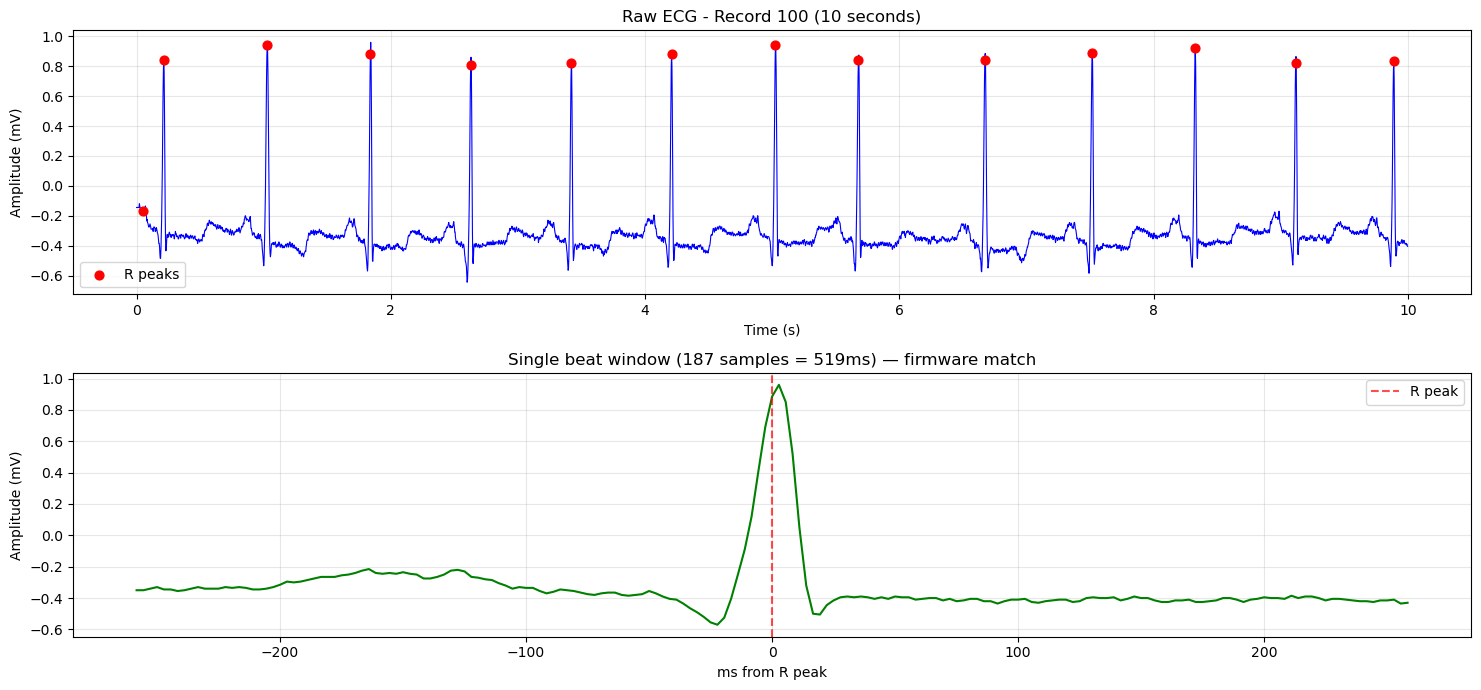

In [3]:
# Quick sanity check on data
record     = wfdb.rdrecord(f'{MITBIH_PATH}/100')
annotation = wfdb.rdann(f'{MITBIH_PATH}/100', 'atr')

print("=== RECORD 100 INFO ===")
print(f"Signal names : {record.sig_name}")
print(f"Sampling freq: {record.fs} Hz")
print(f"Signal length: {record.sig_len} samples ({record.sig_len/record.fs/60:.1f} min)")
print(f"Annotations  : {len(annotation.sample)} beats")
print(f"Unique symbols: {sorted(set(annotation.symbol))}")

# Plot 10s of signal + a single beat window at 187 samples
signal = record.p_signal[:, 0]
fig, axes = plt.subplots(2, 1, figsize=(15, 7))
t = np.arange(0, 10 * FS) / FS
axes[0].plot(t, signal[:10*FS], 'b-', linewidth=0.8)
r_in_window = [p for p in annotation.sample if p < 10*FS]
axes[0].scatter([p/FS for p in r_in_window], [signal[p] for p in r_in_window],
                color='red', s=40, zorder=5, label='R peaks')
axes[0].set_title('Raw ECG - Record 100 (10 seconds)')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Single 187-sample window
center = r_in_window[3]
t2 = np.arange(-WINDOW_PRE, WINDOW_POST) / FS * 1000
axes[1].plot(t2, signal[center-WINDOW_PRE : center+WINDOW_POST], 'g-', linewidth=1.5)
axes[1].axvline(x=0, color='red', alpha=0.7, linestyle='--', label='R peak')
axes[1].set_title(f'Single beat window ({WINDOW_LEN} samples = {WINDOW_LEN/FS*1000:.0f}ms) — firmware match')
axes[1].set_xlabel('ms from R peak'); axes[1].set_ylabel('Amplitude (mV)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/ecg_exploration.png', dpi=150, bbox_inches='tight')
plt.show()


In [4]:
# NLMS filter — Python port of tarang_nlms.c
# MIT-BIH has no IMU data so this runs as passthrough during training.
# Kept here as ground-truth reference matching the C implementation.

NLMS_TAPS          = 32
NLMS_MU            = 0.01           # DEFAULT_MU_Q15 / 32768
NLMS_EPS           = 1e-6
MOTION_GATE_THRESH = 200 / 16384.0  # LSB threshold → normalized g
GRAVITY_BASELINE   = 1.0            # 1g

def nlms_filter(ecg_raw_uint16, imu_accel_xyz_array):
    N = len(ecg_raw_uint16)
    ecg_centered = ecg_raw_uint16.astype(np.float32) - 2048.0
    if imu_accel_xyz_array is None or len(imu_accel_xyz_array) == 0:
        return ecg_centered
    mag = np.sqrt(np.sum(imu_accel_xyz_array.astype(np.float64)**2, axis=1))
    mag_normalized = mag / 16384.0
    M = len(mag_normalized)
    imu_upsampled = np.repeat(mag_normalized, int(np.ceil(N / M)))[:N]
    ref_signal = imu_upsampled - GRAVITY_BASELINE
    motion_detected = np.max(np.abs(ref_signal)) > MOTION_GATE_THRESH
    weights = np.zeros(NLMS_TAPS, dtype=np.float64)
    delay   = np.zeros(NLMS_TAPS, dtype=np.float64)
    ecg_clean = np.zeros(N, dtype=np.float32)
    for i in range(N):
        delay = np.roll(delay, 1)
        delay[0] = ref_signal[i]
        y_est = np.dot(weights, delay)
        error = ecg_centered[i] - y_est
        if not motion_detected:
            ecg_clean[i] = ecg_centered[i]
            continue
        x_power = np.dot(delay, delay)
        if x_power + NLMS_EPS > 0:
            weights += (NLMS_MU / (x_power + NLMS_EPS)) * error * delay
        ecg_clean[i] = np.clip(error, -32768, 32767)
    return ecg_clean

print("NLMS filter defined (passthrough for MIT-BIH/SVDB — no IMU data in public datasets)")


NLMS filter defined (passthrough for MIT-BIH/SVDB — no IMU data in public datasets)


In [5]:
def rolling_window_normalize(signal, window_samples=10800):
    """Simulates firmware Welford online variance (30s sliding window at 360Hz)."""
    series  = pd.Series(signal)
    rolling = series.rolling(window=window_samples, min_periods=1)
    mean    = rolling.mean()
    std     = rolling.std().fillna(1e-8)
    std[std < 1e-8] = 1e-8
    return ((series - mean) / std).values

def compute_rr_features(peaks, beat_idx):
    """
    Extract 5 RR-interval features for a single beat.
    peaks: full sorted array of R-peak sample indices for this record
    beat_idx: index of the current beat in peaks[]

    Returns float32 array of shape (5,):
        [rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5]
    All in seconds (divide by FS).

    Firmware replicates this from the Pan-Tompkins RR buffer already maintained.
    Edge handling: clamp to nearest valid neighbor.
    """
    n = len(peaks)
    i = beat_idx

    # prev/next RR (seconds), clamped at edges
    prev_idx = max(0, i - 1)
    next_idx = min(n - 1, i + 1)
    rr_prev = (peaks[i] - peaks[prev_idx]) / FS
    rr_next = (peaks[next_idx] - peaks[i]) / FS

    # ratio: how early is this beat relative to next?
    # S beats are early → rr_prev short, rr_ratio < 1
    rr_ratio = rr_prev / max(rr_next, 1e-4)

    # local rhythm context: mean and std of 5-beat window
    lo = max(0, i - 2)
    hi = min(n - 1, i + 2)
    local_rrs = np.diff(peaks[lo:hi+1]).astype(np.float32) / FS
    if len(local_rrs) == 0:
        rr_mean_5, rr_std_5 = rr_prev, 0.0
    else:
        rr_mean_5 = float(np.mean(local_rrs))
        rr_std_5  = float(np.std(local_rrs))

    return np.array([rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5], dtype=np.float32)

print("Rolling normalize + RR feature extractor defined.")


Rolling normalize + RR feature extractor defined.


In [6]:
def load_records(db_path, record_list, source_tag, two_channel=True):
    """
    Load beats from a list of records in db_path.
    Returns: beats (N, WINDOW_LEN, ch), rr_feats (N, 5), labels (N,), record_ids (N,)
    """
    all_beats   = []
    all_rr      = []
    all_labels  = []
    all_recs    = []

    for rec_id in record_list:
        rec_str = str(rec_id)
        try:
            record     = wfdb.rdrecord(f'{db_path}/{rec_str}')
            annotation = wfdb.rdann(f'{db_path}/{rec_str}', 'atr')

            ecg_ch0 = rolling_window_normalize(record.p_signal[:, 0])
            if two_channel and record.p_signal.shape[1] > 1:
                ecg_ch1 = rolling_window_normalize(record.p_signal[:, 1])
            else:
                ecg_ch1 = ecg_ch0   # SVDB is single-lead: duplicate channel

            # Build peak list for RR feature extraction
            all_peaks  = annotation.sample
            all_syms   = annotation.symbol
            valid_mask = [BEAT_MAP.get(s, None) in CLASSES_TO_USE for s in all_syms]
            # We need ALL peaks for RR context, but only store valid beats
            valid_peak_indices = [i for i, v in enumerate(valid_mask) if v]

            beats_this = 0
            for idx in valid_peak_indices:
                peak   = all_peaks[idx]
                mapped = BEAT_MAP[all_syms[idx]]

                if peak - WINDOW_PRE < 0 or peak + WINDOW_POST >= len(ecg_ch0):
                    continue

                beat = np.stack([
                    ecg_ch0[peak - WINDOW_PRE : peak + WINDOW_POST],
                    ecg_ch1[peak - WINDOW_PRE : peak + WINDOW_POST]
                ], axis=-1)  # (187, 2)

                if np.any(np.isnan(beat)) or np.any(np.isinf(beat)):
                    continue

                # RR features from ALL peaks in the record (not just valid beats)
                rr = compute_rr_features(all_peaks, idx)

                all_beats.append(beat)
                all_rr.append(rr)
                all_labels.append(mapped)
                all_recs.append(f'{source_tag}_{rec_str}')
                beats_this += 1

            print(f"  {source_tag}/{rec_str}: {beats_this} beats")

        except Exception as ex:
            print(f"  {source_tag}/{rec_str}: FAILED — {ex}")

    return (
        np.array(all_beats,  dtype=np.float32),   # (N, 187, 2)
        np.array(all_rr,     dtype=np.float32),   # (N, 5)
        np.array(all_labels, dtype=object),        # (N,)
        np.array(all_recs,   dtype=object),        # (N,)
    )


print("Loading MIT-BIH Arrhythmia database...")
mb_beats, mb_rr, mb_labels, mb_recs = load_records(
    MITBIH_PATH, MITBIH_ALL_RECORDS, 'mitbih', two_channel=True
)

print(f"\nMIT-BIH loaded: {mb_beats.shape}  classes={Counter(mb_labels)}")


Loading MIT-BIH Arrhythmia database...
  mitbih/100: 2271 beats
  mitbih/101: 1862 beats
  mitbih/102: 103 beats
  mitbih/103: 2084 beats
  mitbih/104: 165 beats
  mitbih/105: 2567 beats
  mitbih/106: 2027 beats
  mitbih/107: 59 beats
  mitbih/108: 1762 beats
  mitbih/109: 2531 beats
  mitbih/111: 2124 beats
  mitbih/112: 2539 beats
  mitbih/113: 1794 beats
  mitbih/114: 1879 beats
  mitbih/115: 1952 beats
  mitbih/116: 2411 beats
  mitbih/117: 1534 beats
  mitbih/118: 2277 beats
  mitbih/119: 1987 beats
  mitbih/121: 1863 beats
  mitbih/122: 2476 beats
  mitbih/123: 1517 beats
  mitbih/124: 1619 beats
  mitbih/200: 2600 beats
  mitbih/201: 1963 beats
  mitbih/202: 2136 beats
  mitbih/203: 2976 beats
  mitbih/205: 2656 beats
  mitbih/207: 1859 beats
  mitbih/208: 2951 beats
  mitbih/209: 3005 beats
  mitbih/210: 2648 beats
  mitbih/212: 2747 beats
  mitbih/213: 3250 beats
  mitbih/214: 2259 beats
  mitbih/215: 3363 beats
  mitbih/217: 406 beats
  mitbih/219: 2154 beats
  mitbih/220: 20

In [7]:
print("Loading MIT-BIH SVDB (Supraventricular Arrhythmia Database)...")
svdb_ok = os.path.isdir(SVDB_PATH)

if svdb_ok:
    sv_beats, sv_rr, sv_labels, sv_recs = load_records(
        SVDB_PATH, SVDB_RECORDS, 'svdb', two_channel=False
    )
    print(f"\nSVDB loaded: {sv_beats.shape}  classes={Counter(sv_labels)}")
else:
    print(f"\nWARNING: SVDB not found at {SVDB_PATH}")
    print("Training will proceed with MIT-BIH only.")
    print("To add SVDB: wfdb.dl_database('svdb', dl_dir=SVDB_PATH)")
    sv_beats  = np.empty((0, WINDOW_LEN, 2), dtype=np.float32)
    sv_rr     = np.empty((0, 5),             dtype=np.float32)
    sv_labels = np.array([], dtype=object)
    sv_recs   = np.array([], dtype=object)


Loading MIT-BIH SVDB (Supraventricular Arrhythmia Database)...

Training will proceed with MIT-BIH only.
To add SVDB: wfdb.dl_database('svdb', dl_dir=SVDB_PATH)


Label encoding:
  0 = N
  1 = S
  2 = V

X shape     : (101426, 187, 2)  (beats, 187 samples, 2 channels)
X_rr shape  : (101426, 5)  (beats, 5 RR features)

Train: 34,467  Counter({'N': 31125, 'S': 1695, 'V': 1647})
Val  : 8,492   Counter({'N': 8017, 'V': 350, 'S': 125})
Test : 58,467  Counter({'N': 51466, 'V': 6040, 'S': 961})


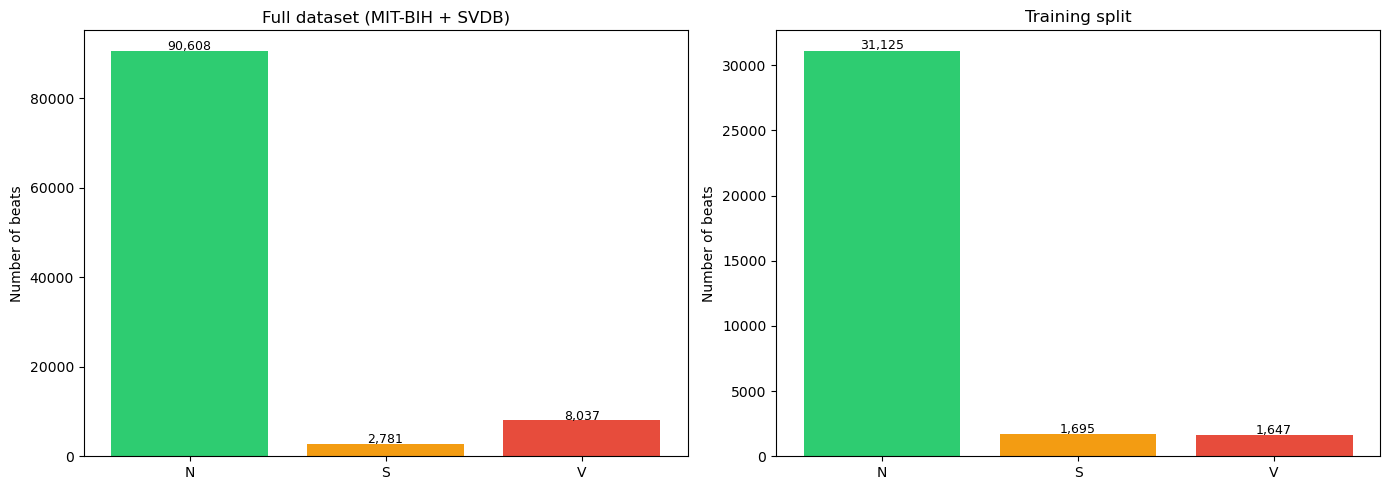

In [8]:
# Combine both datasets
X_all      = np.concatenate([mb_beats, sv_beats], axis=0)
X_rr_all   = np.concatenate([mb_rr,    sv_rr],   axis=0)
y_raw_all  = np.concatenate([mb_labels, sv_labels])
recs_all   = np.concatenate([mb_recs,   sv_recs])

# Label encode on combined
le = LabelEncoder()
y_all = le.fit_transform(y_raw_all)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} = {cls}")

# Split: MIT-BIH test records only (patient-wise)
#        SVDB = train only (tagged 'svdb_*')
test_mask  = np.array([r.startswith('mitbih_') and int(r.split('_')[1]) in MITBIH_TEST_RECORDS
                        for r in recs_all])
val_mask   = np.array([r.startswith('mitbih_') and int(r.split('_')[1]) in MITBIH_VAL_RECORDS
                        for r in recs_all])
train_mask = ~test_mask & ~val_mask   # everything else (MIT-BIH train + all SVDB)

X_train,    X_val,    X_test    = X_all[train_mask],    X_all[val_mask],    X_all[test_mask]
X_rr_train, X_rr_val, X_rr_test = X_rr_all[train_mask], X_rr_all[val_mask], X_rr_all[test_mask]
y_train,    y_val,    y_test    = y_all[train_mask],    y_all[val_mask],    y_all[test_mask]

print(f"\nX shape     : {X_all.shape}  (beats, {WINDOW_LEN} samples, 2 channels)")
print(f"X_rr shape  : {X_rr_all.shape}  (beats, 5 RR features)")
print(f"\nTrain: {len(X_train):,}  {Counter(le.inverse_transform(y_train))}")
print(f"Val  : {len(X_val):,}   {Counter(le.inverse_transform(y_val))}")
print(f"Test : {len(X_test):,}  {Counter(le.inverse_transform(y_test))}")

# Class distribution plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#2ecc71', '#f39c12', '#e74c3c']
classes_list = list(le.classes_)
total_counter = Counter(y_raw_all)
train_counter = Counter(le.inverse_transform(y_train))

for ax, ctr, title in zip(axes,
                           [total_counter, train_counter],
                           ['Full dataset (MIT-BIH + SVDB)', 'Training split']):
    counts = [ctr.get(c, 0) for c in classes_list]
    ax.bar(classes_list, counts, color=colors)
    ax.set_title(title)
    ax.set_ylabel('Number of beats')
    for i, v in enumerate(counts):
        ax.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/class_distribution.png', dpi=100)
plt.show()


In [9]:
def augment_batch(X_c, X_rr_c, class_name, n_copies):
    """
    Augment ECG waveforms AND corresponding RR features.
    X_c:    (n, WINDOW_LEN, 2)
    X_rr_c: (n, 5)  [rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5]
    Returns: aug_ecg (n*n_copies, WINDOW_LEN, 2), aug_rr (n*n_copies, 5)
    """
    n = len(X_c)
    ecg_aug_list = []
    rr_aug_list  = []

    for _ in range(n_copies):
        # ── ECG augmentations ──────────────────────────────────────────────────
        a = X_c.copy()  # (n, WINDOW_LEN, 2)

        # 1. Amplitude scaling ±15% (same for both channels)
        scale = np.random.uniform(0.85, 1.15, (n, 1, 1))
        a *= scale

        # 2. Baseline wander (0.3–0.8 Hz)
        t_arr  = np.linspace(0, 2 * np.pi, WINDOW_LEN)
        freqs  = np.random.uniform(0.3, 0.8, n)
        amps   = np.random.uniform(0.0, 0.12, n)
        wander = (amps[:, None] * np.sin(freqs[:, None] * t_arr[None, :]))[:, :, None]
        a     += wander  # broadcast over channels

        # 3. Gaussian noise
        a += np.random.normal(0, np.random.uniform(0.01, 0.04), a.shape).astype(np.float32)

        # 4. Time shift ±10 samples (smaller than v2's ±20 — 187-sample window is tighter)
        shifts = np.random.randint(-10, 11, n)
        for i in range(n):
            a[i] = np.roll(a[i], shifts[i], axis=0)

        # 5. S only: P-wave perturbation (first ~40 samples = 111ms before QRS)
        if class_name == 'S':
            a[:, :40, :] *= np.random.uniform(0.4, 1.6, (n, 1, 1))

        ecg_aug_list.append(a.astype(np.float32))

        # ── RR feature augmentation ───────────────────────────────────────────
        rr = X_rr_c.copy()  # (n, 5): [rr_prev, rr_next, rr_ratio, rr_mean_5, rr_std_5]

        if class_name == 'S':
            # S = premature beat: rr_prev shorter, rr_ratio < 1, higher local variability
            rr[:, 0] *= np.random.uniform(0.6, 0.95, n)    # rr_prev shorter
            rr[:, 2]  = rr[:, 0] / np.maximum(rr[:, 1], 1e-4)  # recompute ratio
            rr[:, 4] *= np.random.uniform(1.1, 1.5, n)     # rr_std_5 higher (irregular)
        elif class_name == 'V':
            # V = PVC: compensatory pause (rr_next longer), slightly variable
            rr[:, 1] *= np.random.uniform(1.05, 1.2, n)    # rr_next slightly longer
            rr[:, 4] *= np.random.uniform(1.0, 1.3, n)

        # Small ±5% jitter on all RR features to prevent overfitting
        rr *= np.random.uniform(0.95, 1.05, rr.shape)
        rr  = np.clip(rr, 0.0, 3.0).astype(np.float32)  # max 3s RR = 20 bpm floor
        rr_aug_list.append(rr)

    return (
        np.concatenate(ecg_aug_list, axis=0),
        np.concatenate(rr_aug_list,  axis=0),
    )


# N: no augmentation (majority class)
# V: 5 extra copies → 6x total
# S: 10 extra copies → 11x total  (S-class is the weakest, needs most help)
AUG_COPIES = {'N': 0, 'V': 5, 'S': 10}

print("Augmenting minority classes...")
ecg_aug_list = [X_train]
rr_aug_list  = [X_rr_train]
y_aug_list   = [y_train]

for class_idx, class_name in enumerate(le.classes_):
    n_copies = AUG_COPIES.get(class_name, 0)
    if n_copies == 0:
        continue
    mask = y_train == class_idx
    aug_ecg, aug_rr = augment_batch(X_train[mask], X_rr_train[mask], class_name, n_copies)
    ecg_aug_list.append(aug_ecg)
    rr_aug_list.append(aug_rr)
    y_aug_list.append(np.tile(y_train[mask], n_copies))

X_train_aug    = np.concatenate(ecg_aug_list, axis=0)
X_rr_train_aug = np.concatenate(rr_aug_list,  axis=0)
y_train_aug    = np.concatenate(y_aug_list,   axis=0)

# Shuffle
idx = np.random.permutation(len(X_train_aug))
X_train_aug    = X_train_aug[idx]
X_rr_train_aug = X_rr_train_aug[idx]
y_train_aug    = y_train_aug[idx]

print(f"Before aug : {Counter(le.inverse_transform(y_train))}")
print(f"After aug  : {Counter(le.inverse_transform(y_train_aug))}")
print(f"Total beats: {len(X_train_aug):,}")
print(f"ECG shape  : {X_train_aug.shape}")
print(f"RR shape   : {X_rr_train_aug.shape}")


Augmenting minority classes...
Before aug : Counter({'N': 31125, 'S': 1695, 'V': 1647})
After aug  : Counter({'N': 31125, 'S': 18645, 'V': 9882})
Total beats: 59,652
ECG shape  : (59652, 187, 2)
RR shape   : (59652, 5)


In [10]:
def build_tarang_cnn_v3(ecg_shape=(WINDOW_LEN, 2), rr_shape=(5,), num_classes=3):
    """
    Dual-input model:
      Branch 1: ECG waveform (WINDOW_LEN, 2) — depthwise separable 1D CNN
      Branch 2: RR features  (5,)             — small dense network
      Concat → Dense(32) → softmax

    Depthwise separable convolutions:
      - Same accuracy as standard Conv1D with ~5-8x fewer params
      - Better suited for MVP accelerator (fewer MAC operations per inference)
      - Keeps INT8 model well under 50KB
    """
    # ── ECG branch ─────────────────────────────────────────────────────────────
    ecg_in = tf.keras.Input(shape=ecg_shape, name='ecg_input')

    # Block 1 — local waveform / P-wave detection
    x = tf.keras.layers.SeparableConv1D(
        16, 7, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4)
    )(ecg_in)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)           # → (93, 16)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 2 — QRS morphology
    x = tf.keras.layers.SeparableConv1D(
        32, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.MaxPooling1D(2)(x)           # → (46, 32)
    x = tf.keras.layers.SpatialDropout1D(0.1)(x)

    # Block 3 — T wave / ST segment
    x = tf.keras.layers.SeparableConv1D(
        64, 5, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.SpatialDropout1D(0.15)(x)

    # Block 4 — S-class discrimination capacity
    x = tf.keras.layers.SeparableConv1D(
        64, 3, padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(1e-4)
    )(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)

    x = tf.keras.layers.GlobalAveragePooling1D()(x)  # → (64,)

    # ── RR feature branch ──────────────────────────────────────────────────────
    rr_in = tf.keras.Input(shape=rr_shape, name='rr_input')
    r = tf.keras.layers.Dense(16, activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(rr_in)
    r = tf.keras.layers.Dense(8,  activation='relu',
                               kernel_regularizer=regularizers.l2(1e-4))(r)

    # ── Merge ──────────────────────────────────────────────────────────────────
    merged = tf.keras.layers.Concatenate()([x, r])     # (72,)
    merged = tf.keras.layers.Dense(32, use_bias=False)(merged)
    merged = tf.keras.layers.BatchNormalization()(merged)
    merged = tf.keras.layers.Activation('relu')(merged)
    merged = tf.keras.layers.Dropout(0.35)(merged)

    outputs = tf.keras.layers.Dense(num_classes, activation='softmax',
                                    name='predictions')(merged)

    return tf.keras.Model(inputs=[ecg_in, rr_in], outputs=outputs, name='Tarang_ECG_v3')


model = build_tarang_cnn_v3(num_classes=len(le.classes_))
model.summary()

total_params = model.count_params()
print(f"\nParameters: {total_params:,}")
print(f"Est. INT8 : ~{total_params/1024:.1f} KB  "
      f"({'PASS' if total_params < 51200 else 'OVER 50KB — reduce capacity'})")


Model: "Tarang_ECG_v3"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 ecg_input (InputLayer)         [(None, 187, 2)]     0           []                               
                                                                                                  
 separable_conv1d (SeparableCon  (None, 187, 16)     46          ['ecg_input[0][0]']              
 v1D)                                                                                             
                                                                                                  
 batch_normalization (BatchNorm  (None, 187, 16)     64          ['separable_conv1d[0][0]']       
 alization)                                                                                       
                                                                                      

In [12]:
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, alpha, gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self.alpha = tf.constant(alpha, dtype=tf.float32)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_true        = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred        = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        y_onehot      = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])
        cross_entropy = -y_onehot * tf.math.log(y_pred)
        pt            = tf.reduce_sum(y_onehot * y_pred, axis=-1)
        focal_weight  = tf.pow(1.0 - pt, self.gamma)
        alpha_weight  = tf.reduce_sum(self.alpha * y_onehot, axis=-1)
        loss          = alpha_weight * focal_weight * tf.reduce_sum(cross_entropy, axis=-1)
        return tf.reduce_mean(loss)

# N=0.15 (majority, downweighted), S=0.50 (hardest class), V=0.35
# label order follows le.classes_ which is alphabetical: N, S, V → [0.15, 0.50, 0.35]
focal_alpha = [0.15, 0.50, 0.35]
focal_gamma = 2.0
print(f'Focal Loss: alpha={focal_alpha} (order: {list(le.classes_)}), gamma={focal_gamma}')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=SparseFocalLoss(alpha=focal_alpha, gamma=focal_gamma),
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=20,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=8, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        MODEL_CHECKPOINT, monitor='val_loss',
        save_best_only=True, verbose=0
    ),
]

history = model.fit(
    [X_train_aug, X_rr_train_aug], y_train_aug,
    validation_data=([X_val, X_rr_val], y_val),
    epochs=150,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

with open(f'{OUTPUTS_DIR}/training_history.json', 'w') as f:
    json.dump({k: [float(x) for x in v] for k, v in history.history.items()}, f)


Focal Loss: alpha=[0.15, 0.5, 0.35] (order: ['N', 'S', 'V']), gamma=2.0
Epoch 1/150
1865/1865 [==============================] - 68s 34ms/step - loss: 0.0095 - accuracy: 0.9660 - val_loss: 0.0442 - val_accuracy: 0.8959 - lr: 5.0000e-04
Epoch 2/150
1865/1865 [==============================] - 69s 37ms/step - loss: 0.0087 - accuracy: 0.9684 - val_loss: 0.0492 - val_accuracy: 0.8347 - lr: 5.0000e-04
Epoch 3/150
1865/1865 [==============================] - 43s 23ms/step - loss: 0.0084 - accuracy: 0.9706 - val_loss: 0.0535 - val_accuracy: 0.4542 - lr: 5.0000e-04
Epoch 4/150
1865/1865 [==============================] - 38s 20ms/step - loss: 0.0077 - accuracy: 0.9719 - val_loss: 0.0567 - val_accuracy: 0.2309 - lr: 5.0000e-04
Epoch 5/150
1865/1865 [==============================] - 37s 20ms/step - loss: 0.0078 - accuracy: 0.9721 - val_loss: 0.0596 - val_accuracy: 0.2222 - lr: 5.0000e-04
Epoch 6/150
1865/1865 [==============================] - 38s 20ms/step - loss: 0.0076 - accuracy: 0.9726 - v

In [13]:
print('\n' + '='*60)
print('THRESHOLD TUNING on validation set')
print('='*60)

model = tf.keras.models.load_model(
    MODEL_CHECKPOINT,
    custom_objects={'SparseFocalLoss': SparseFocalLoss},
    compile=False
)

y_val_probs = model.predict([X_val, X_rr_val], batch_size=128)

n_idx = int(np.where(le.classes_ == 'N')[0])
s_idx = int(np.where(le.classes_ == 'S')[0])
v_idx = int(np.where(le.classes_ == 'V')[0])

best_macro_f1   = 0.0
best_thresholds = {'S': 0.5, 'V': 0.5}
best_v_recall   = 0.0

for t_v in np.arange(0.10, 0.55, 0.02):
    for t_s in np.arange(0.10, 0.60, 0.02):
        y_pred = np.full(len(y_val), n_idx, dtype=int)
        y_pred[y_val_probs[:, s_idx] > t_s] = s_idx
        y_pred[y_val_probs[:, v_idx] > t_v] = v_idx   # V overrides S

        v_recall = (np.sum((y_val == v_idx) & (y_pred == v_idx))
                    / max(np.sum(y_val == v_idx), 1))
        if v_recall < 0.85:    # hard floor — missing PVC is a patient safety issue
            continue

        macro = f1_score(y_val, y_pred, average='macro', zero_division=0)
        if macro > best_macro_f1:
            best_macro_f1   = macro
            best_v_recall   = v_recall
            best_thresholds = {'S': round(t_s, 2), 'V': round(t_v, 2)}

print(f'Best thresholds : S > {best_thresholds["S"]},  V > {best_thresholds["V"]}')
print(f'V recall at best: {best_v_recall:.3f}  (floor: 0.85)')
print(f'Best val macro F1: {best_macro_f1:.3f}')

# ── Evaluate on test set ────────────────────────────────────────────────────────
print('\n' + '='*60)
print('EVALUATION — TUNED THRESHOLDS on held-out test set (MIT-BIH patient-wise)')
print('='*60)

y_pred_probs     = model.predict([X_test, X_rr_test], batch_size=128)
y_pred_test      = np.full(len(y_test), n_idx, dtype=int)
y_pred_test[y_pred_probs[:, s_idx] > best_thresholds['S']] = s_idx
y_pred_test[y_pred_probs[:, v_idx] > best_thresholds['V']] = v_idx

print(classification_report(y_test, y_pred_test, target_names=le.classes_))

f1_per_class  = f1_score(y_test, y_pred_test, average=None, zero_division=0)
macro_f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
print(f'Macro F1 (tuned): {macro_f1_test:.3f}')
for cls, f1 in zip(le.classes_, f1_per_class):
    status = 'PASS ✓' if f1 >= 0.85 else 'NEEDS WORK'
    print(f'  F1 {cls}: {f1:.3f}  [{status}]')

cm_tuned = confusion_matrix(y_test, y_pred_test)
print(f'\nConfusion Matrix:')
print(cm_tuned)



THRESHOLD TUNING on validation set
67/67 [==============================] - 1s 6ms/step
Best thresholds : S > 0.44,  V > 0.44
V recall at best: 0.860  (floor: 0.85)
Best val macro F1: 0.634

EVALUATION — TUNED THRESHOLDS on held-out test set (MIT-BIH patient-wise)
457/457 [==============================] - 2s 4ms/step
              precision    recall  f1-score   support

           N       0.98      0.78      0.87     51466
           S       0.10      0.34      0.16       961
           V       0.36      0.85      0.51      6040

    accuracy                           0.78     58467
   macro avg       0.48      0.66      0.51     58467
weighted avg       0.90      0.78      0.82     58467

Macro F1 (tuned): 0.512
  F1 N: 0.869  [PASS ✓]
  F1 S: 0.158  [NEEDS WORK]
  F1 V: 0.510  [NEEDS WORK]

Confusion Matrix:
[[40257  2458  8751]
 [  394   327   240]
 [  500   393  5147]]


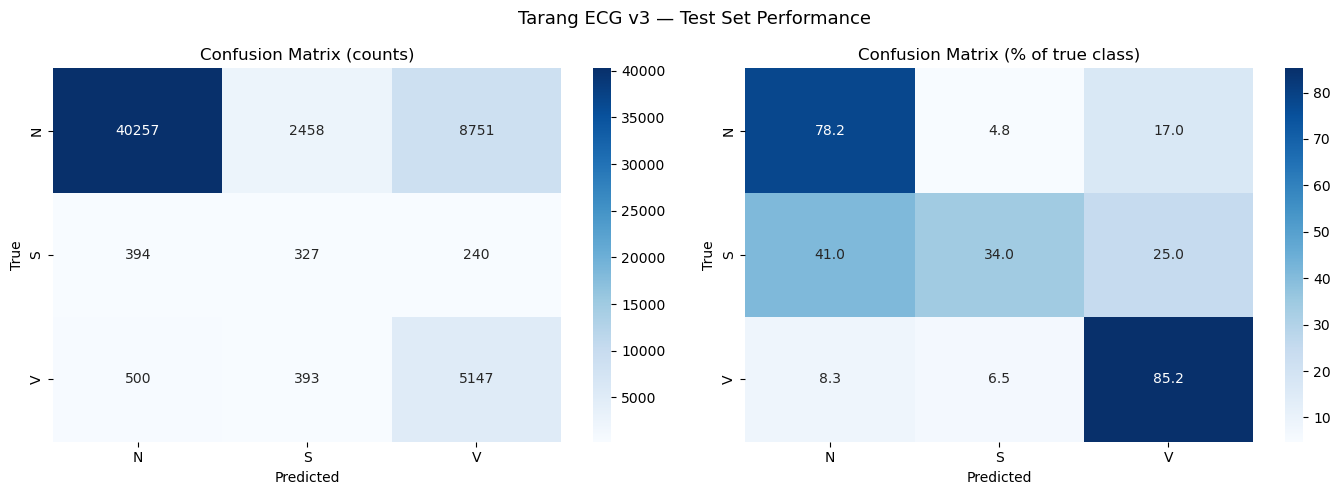

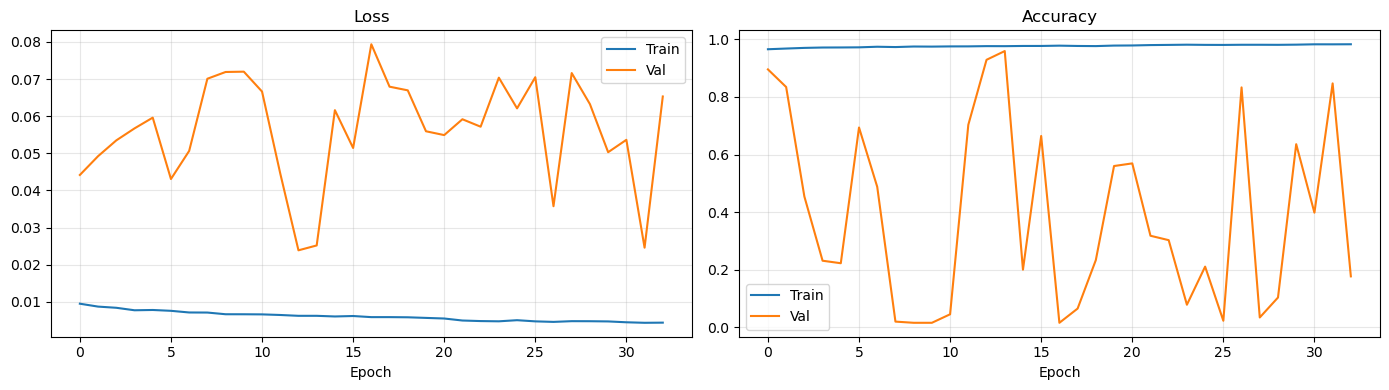

In [14]:
try:
    hist_data = history.history
except NameError:
    with open(f'{OUTPUTS_DIR}/training_history.json') as f:
        hist_data = json.load(f)

cm     = confusion_matrix(y_test, y_pred_test)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[1])
axes[1].set_title('Confusion Matrix (% of true class)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle('Tarang ECG v3 — Test Set Performance', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_data['loss'],     label='Train'); axes[0].plot(hist_data['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(hist_data['accuracy'], label='Train'); axes[1].plot(hist_data['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [15]:
CONFIDENCE_THRESHOLD = 0.70

model = tf.keras.models.load_model(
    MODEL_CHECKPOINT,
    custom_objects={'SparseFocalLoss': SparseFocalLoss},
    compile=False
)

# Compute RR feature normalization stats from CLEAN training data (not augmented).
# Firmware must apply the same normalization before passing RR features to the model.
RR_MEAN = X_rr_train.mean(axis=0)
RR_STD  = X_rr_train.std(axis=0)
RR_STD[RR_STD < 1e-8] = 1e-8

X_rr_train_norm = (X_rr_train - RR_MEAN) / RR_STD
X_rr_val_norm   = (X_rr_val   - RR_MEAN) / RR_STD
X_rr_test_norm  = (X_rr_test  - RR_MEAN) / RR_STD

print("RR normalization stats (copy to firmware):")
feature_names = ['rr_prev', 'rr_next', 'rr_ratio', 'rr_mean_5', 'rr_std_5']
for i, name in enumerate(feature_names):
    print(f"  {name}: mean={RR_MEAN[i]:.5f}, std={RR_STD[i]:.5f}")

# ── Representative dataset: both inputs, balanced, raw (not augmented) ──────────
def representative_dataset():
    idx = np.random.choice(len(X_train), min(1000, len(X_train)), replace=False)
    for i in idx:
        ecg_sample = X_train[i:i+1].astype(np.float32)
        rr_sample  = ((X_rr_train[i:i+1] - RR_MEAN) / RR_STD).astype(np.float32)
        yield [ecg_sample, rr_sample]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations              = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset     = representative_dataset
converter.target_spec.supported_ops  = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type       = tf.int8
converter.inference_output_type      = tf.int8

print("\nQuantizing to INT8...")
tflite_model = converter.convert()
print("Done.")

with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_kb = len(tflite_model) / 1024
print(f"\nINT8 model size: {size_kb:.1f} KB")
print(f"Target < 50 KB : {'PASS ✓' if size_kb < 50 else 'FAIL — reduce capacity'}")

interp = tf.lite.Interpreter(model_content=tflite_model)
interp.allocate_tensors()

input_details  = interp.get_input_details()
output_details = interp.get_output_details()

# TFLite names inputs in graph order — identify which is ECG vs RR by shape
ecg_det = next(d for d in input_details if d['shape'][1] == WINDOW_LEN)
rr_det  = next(d for d in input_details if d['shape'][1] == 5)
out_det = output_details[0]

ecg_scale, ecg_zp = ecg_det['quantization']
rr_scale,  rr_zp  = rr_det['quantization']
out_scale, out_zp  = out_det['quantization']

print(f"\nInput ECG  quantization: scale={ecg_scale:.6f}, zero_point={ecg_zp}")
print(f"Input RR   quantization: scale={rr_scale:.6f},  zero_point={rr_zp}")
print(f"Output     quantization: scale={out_scale:.6f}, zero_point={out_zp}")

if ecg_scale > 0.1:
    print(f"\nWARNING: ecg_scale={ecg_scale:.4f} is high (expect ~0.03 for z-score ECG)")

print("\n" + "="*55)
print("COPY THESE DEFINES INTO YOUR C FIRMWARE")
print("="*55)
print(f"// ECG waveform input")
print(f"#define ECG_INPUT_SCALE       {ecg_scale:.8f}f")
print(f"#define ECG_INPUT_ZERO_POINT  {ecg_zp}")
print(f"// RR feature input (normalize before quantizing)")
print(f"#define RR_INPUT_SCALE        {rr_scale:.8f}f")
print(f"#define RR_INPUT_ZERO_POINT   {rr_zp}")
print(f"// Output")
print(f"#define OUTPUT_SCALE          {out_scale:.8f}f")
print(f"#define OUTPUT_ZERO_POINT     {out_zp}")
print(f"#define CONFIDENCE_THRESH_INT8 {int(round(CONFIDENCE_THRESHOLD / out_scale + out_zp))}")
print(f"// RR feature normalization (apply BEFORE RR_INPUT_SCALE quantization)")
for i, name in enumerate(feature_names):
    print(f"#define RR_MEAN_{name.upper():<12} {RR_MEAN[i]:.6f}f")
for i, name in enumerate(feature_names):
    print(f"#define RR_STD_{name.upper():<13} {RR_STD[i]:.6f}f")


RR normalization stats (copy to firmware):
  rr_prev: mean=0.78338, std=0.25890
  rr_next: mean=0.78577, std=0.25690
  rr_ratio: mean=3.02279, std=125.21620
  rr_mean_5: mean=0.78137, std=0.21611
  rr_std_5: mean=0.06552, std=0.12969

Quantizing to INT8...


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp44e8187k\assets


INFO:tensorflow:Assets written to: C:\Users\namda\AppData\Local\Temp\tmp44e8187k\assets


RuntimeError: tensorflow/lite/kernels/depthwise_conv.cc:116 NumDimensions(input) != 4 (3 != 4)Node number 3 (DEPTHWISE_CONV_2D) failed to prepare.

In [ ]:
# Verify INT8 accuracy — target: drop < 3% vs float32
n = min(2000, len(X_test))
X_ecg_sample = X_test[:n]
X_rr_sample  = X_rr_test_norm[:n]
y_sample      = y_test[:n]

# Float32 baseline
float_preds = np.argmax(
    model.predict([X_ecg_sample, (X_rr_test[:n] - RR_MEAN) / RR_STD], batch_size=128, verbose=0),
    axis=1
)
float_acc = np.mean(float_preds == y_sample) * 100

# INT8 inference
correct_int8 = 0
for i in range(n):
    # ECG input
    x_ecg_f = X_ecg_sample[i:i+1].astype(np.float32)
    x_ecg_q = np.clip(np.round(x_ecg_f / ecg_scale + ecg_zp), -128, 127).astype(np.int8)

    # RR input (already normalized)
    x_rr_f = X_rr_sample[i:i+1].astype(np.float32)
    x_rr_q = np.clip(np.round(x_rr_f / rr_scale + rr_zp), -128, 127).astype(np.int8)

    interp.set_tensor(ecg_det['index'], x_ecg_q)
    interp.set_tensor(rr_det['index'],  x_rr_q)
    interp.invoke()

    out_q = interp.get_tensor(out_det['index'])
    out_f = (out_q.astype(np.float32) - out_zp) * out_scale
    if np.argmax(out_f) == y_sample[i]:
        correct_int8 += 1

int8_acc = correct_int8 / n * 100
drop     = float_acc - int8_acc

print(f"Float32 accuracy (n={n}): {float_acc:.2f}%")
print(f"INT8    accuracy (n={n}): {int8_acc:.2f}%")
print(f"Accuracy drop           : {drop:.2f}%")
if drop < 3.0:
    print("ACCEPTABLE ✓")
else:
    print("TOO HIGH — run QAT or check representative_dataset normalization")
    print(f"  ecg_scale={ecg_scale:.6f} (expect ~0.031 for z-score ECG)")
    print(f"  rr_scale ={rr_scale:.6f}")


In [ ]:
try:
    result = subprocess.run(['xxd', '-i', TFLITE_PATH], capture_output=True, text=True)
    xxd_ok = result.returncode == 0 and bool(result.stdout)
except FileNotFoundError:
    xxd_ok = False

if xxd_ok:
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN v3 — INT8 quantized dual-input model\n')
        f.write('// Auto-generated — do not edit\n\n')
        f.write('#pragma once\n\n')
        f.write(result.stdout)
    print(f"Generated {HEADER_PATH}")
    print('\n'.join(result.stdout.split('\n')[:5]))
else:
    # xxd not available (Windows) — Python fallback
    with open(TFLITE_PATH, 'rb') as f:
        data = f.read()
    hex_lines = ['  ' + ', '.join(f'0x{b:02x}' for b in data[i:i+12]) + ','
                 for i in range(0, len(data), 12)]
    with open(HEADER_PATH, 'w') as f:
        f.write('// Tarang ECG CNN v3 — INT8 quantized dual-input model\n')
        f.write('// Auto-generated — do not edit\n\n')
        f.write('#pragma once\n\n')
        f.write(f'#define TARANG_MODEL_LEN {len(data)}\n\n')
        f.write('alignas(8) const unsigned char tarang_int8_tflite[] = {\n')
        f.write('\n'.join(hex_lines))
        f.write('\n};\n')
    print(f"Generated {HEADER_PATH} ({len(data):,} bytes)")


In [ ]:
print('\n' + '='*60)
print('PEAK JITTER ROBUSTNESS TEST')
print('='*60)

def evaluate_with_jitter(model, X_ecg, X_rr, y, jitter_std, thresholds):
    if jitter_std == 0:
        X_jittered = X_ecg
    else:
        jitter = np.random.normal(0, jitter_std, len(X_ecg)).astype(int)
        X_jittered = np.array([np.roll(X_ecg[i], jitter[i], axis=0)
                                for i in range(len(X_ecg))])
    probs = model.predict([X_jittered, X_rr], batch_size=128, verbose=0)
    preds = np.full(len(y), n_idx, dtype=int)
    preds[probs[:, s_idx] > thresholds['S']] = s_idx
    preds[probs[:, v_idx] > thresholds['V']] = v_idx
    return f1_score(y, preds, average='macro', zero_division=0)

X_rr_test_norm_arr = ((X_rr_test - RR_MEAN) / RR_STD).astype(np.float32)

for jitter in [0, 5, 10, 15, 20]:
    f1 = evaluate_with_jitter(model, X_test, X_rr_test_norm_arr,
                               y_test, jitter, best_thresholds)
    print(f"Jitter ±{jitter:2d} samples (~{jitter/FS*1000:.0f}ms): Macro F1 = {f1:.3f}")


In [ ]:
print('\n' + '='*60)
print('BLE EVENT-DRIVEN BURST FILTER (POST-PROCESSING)')
print('='*60)

def apply_run_filter(predictions, min_run=3, window=10):
    """Suppress isolated anomaly predictions — only alert if ≥3 non-N beats in 10-beat window."""
    filtered = predictions.copy()
    for i in range(window, len(predictions)):
        window_preds = predictions[i-window:i]
        if np.sum(window_preds != n_idx) < min_run:
            filtered[i] = n_idx
    return filtered

y_pred_filtered = apply_run_filter(y_pred_test)

print("Raw tuned predictions:")
print(classification_report(y_test, y_pred_test, target_names=le.classes_))
print("After BLE burst filter (isolated anomalies suppressed):")
print(classification_report(y_test, y_pred_filtered, target_names=le.classes_))


## Firmware Integration Notes

### `tarang_ai_process()` — updated call signature

```c
// tarang_ai.h
typedef struct {
    float rr_prev;    // seconds, from Pan-Tompkins buffer
    float rr_next;    // seconds (use 0.0f if next peak not yet detected; model handles it)
    float rr_ratio;   // rr_prev / rr_next
    float rr_mean_5;  // mean of ±2 local RR intervals (seconds)
    float rr_std_5;   // std  of ±2 local RR intervals (seconds)
} tarang_rr_features_t;

tarang_label_t tarang_ai_process(
    const int8_t   *ecg_window_q,    // 187 samples, INT8-quantized, z-score normalized
    const float    *rr_raw,          // rr_features[5], RAW (not yet normalized)
    tarang_conf_t  *conf_out
);
```

### RR normalization in firmware (before RR_INPUT_SCALE quantization)

```c
// 1. Normalize each RR feature:  x_norm = (x_raw - mean) / std
// 2. Quantize:  x_q = clamp(round(x_norm / RR_INPUT_SCALE + RR_INPUT_ZERO_POINT), -128, 127)
// All constants printed by the quantization cell above.
```

### Pan-Tompkins RR buffer
Your existing Pan-Tompkins implementation already maintains an RR ring buffer.  
You need a 5-element window around the current beat. `rr_next` can be filled
as 0.0f (gets normalized + clipped) if the next peak hasn't arrived yet —
the model degrades gracefully since `rr_prev`, `rr_ratio`, and `rr_mean_5` carry
most of the discriminative power for S-class.

### Two-input TFLite Micro invocation

```c
// Set tensor 0 (ECG) and tensor 1 (RR) — indices from tarang_model.h
TfLiteTensor *ecg_tensor = interpreter->input(ECG_TENSOR_IDX);
TfLiteTensor *rr_tensor  = interpreter->input(RR_TENSOR_IDX);
memcpy(ecg_tensor->data.int8, ecg_window_q, WINDOW_LEN * 2 * sizeof(int8_t));
memcpy(rr_tensor->data.int8,  rr_q,         5 * sizeof(int8_t));
TfLiteStatus status = interpreter->Invoke();
```
